## K-Means Clustering: Property Price Categories


* K-means clustering is one of the simplest and popular unsupervised machine learning algorithms. A target number is defined k, which refers to the number of centroids you need in the dataset. A cventroid is the imaginary or real location representing the centre of the cluster. Every data point is allocated to each of the clusters through reducing the in-cluster sum of squares. In other words, the K-means algorithm  identifies k number of centroids and then allocates every datapoint to the nearest cluster, whil keeping the centroids as small as possible.

* In this analysis, we apply K-Means with K=3 to a dataset of 1,925 Irish property listings, using numerical features including Rent_Price, Land_Price, Average_Value_County, Population of County,Average_Value_Bedroom_Count and Net_Income. The goal is to discover whether the algorithm can naturally identify three distinct property tiers Budget, Standard, and Luxury, purely from the numerical patterns in these features, without ever being told the Price_Category label.

* This acts as a form of validation: if the clusters align closely with the manually assigned price categories, it confirms that those labels reflect genuine, data-driven distinctions rather than arbitrary price thresholds. Where mismatches occur, they reveal properties that sit ambiguously on the boundary between categories.

* For a property developer, correctly classifying a new development into the appropriate price tier is critical for competitive pricing strategy. This model provides a data-driven method to assign properties to Budget, Standard, or Luxury tiers based on measurable features, removing reliance on manual judgement alone.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report

In [2]:
## 2. Import & Explore Data

In [3]:
df = pd.read_csv('Data_with_class.csv')
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
df.head()

,Price_Category,Number of Bedrooms,County,Rent_Price,Land_Price,Population of County,Average_Value_County,Rent_To_Land_Ratio,Average_Value_Bedroom_Count,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,Net_Income
0,Standard,Four plus bed,Carlow,1397.92,17417,61968,976.857368,0.080262,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
1,Standard,Four plus bed,Carlow,1323.98,17417,61968,976.857368,0.076017,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
2,Standard,All bedrooms,Carlow,1060.03,17417,61968,976.857368,0.060862,1029.973333,86.53,147.83,25.62,33.55,7.19,53953
3,Standard,Three bed,Carlow,1028.83,17417,61968,976.857368,0.059070,1002.910000,86.53,147.83,25.62,33.55,7.19,53953
4,Standard,All bedrooms,Carlow,1017.06,17417,61968,976.857368,0.058395,1029.973333,86.53,147.83,25.62,33.55,7.19,53953


In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Price_Category                 0
Number of Bedrooms             0
County                         0
Rent_Price                     0
Land_Price                     0
Population of County           0
Average_Value_County           0
Rent_To_Land_Ratio             0
Average_Value_Bedroom_Count    0
vat_internal_€m                0
paye_income_tax_and_usc_€m     0
self_employed_income_tax_€m    0
corporation_tax_€m             0
capital_gains_tax_€m           0
Net_Income                     0
dtype: int64


## 3. Feature Selection & Preparation & Justification:

The six retained features (Rent_Price, Land_Price, Population of
County, Average_Value_County, Net_Income, and
Average_Value_Bedroom_Count), collectively capture the key dimesions of property value in the Irish rental markets demands of land costs, economic prosperity and property size, providing a focused and interpretable basis for the clustering mdoel.

* Rent_Price - the primary indicator of a properties price category, the kost direct feature for seperating Budget, Standard and Luxury listings.
* Land_Price - relfects the underlying value of the location,e.g. higher land prices are strongly associated with premium property categories.
* Population of County - counties with higher populations like Dublin and Cork tend to command higher rents and property values, helping capture urban vs rural pricing differences
* Average_Value_County - represents the general property market level of the county, providing location level context beyond individual listing prices.
* Net_Income - reflects the earning power of residents in each county, wealthier counties are more likely to contain standard and luxury properties.
* Average_Value_Bedroom_Count - links property size to market value, helping the algorithm distinguish larger, higher-value properties from smaller budget ones.


Exclusion of Tax Variables


* vat_internal_€m
* paye_income_tax_and_usc_€m
* self_employed_income_tax_€m
* corporation_tax_€m
* capital_gains_tax_€m

These variables were deliberately excluded from the clustering model for the follwoing reasons:

**Multicollinearity with Net_Income:**
The tax variables are derived from the same underlying economic activity as Net_Income, therefore counties with higher incomes naturally generate higher tax revenues across all categories. Including both Net_Income ansd the tax varibales would only introduce multicolinearity, which possibly could distort cluster formation.

**Indirect Relevance to Property Pricing:**
While tax revenue reflects county-level economic activity, it does not directly influence individual property pricing decisions. As a property development business pricing a development is centred around local factors such as land values, rent prices and householdincome etc. Therefore Net_Income captures the relevant affordability signal without the noise introduced by tax collection figures.

**Silhouette Score Consideration:**
Preliminary exploration confirmed that including the tax variables did not improve the silhouette score, decreased model accuracy and in some cases reduced cluster cohesion, further supporting their exclusion from the clustering model.


In [5]:
features = ["Rent_Price","Land_Price","Population of County","Average_Value_County","Net_Income","Average_Value_Bedroom_Count"]
X = df[features]

print(f"Dataset loaded with {df.shape[0]} rows.")

X.head()

Dataset loaded with 1925 rows.


,Rent_Price,Land_Price,Population of County,Average_Value_County,Net_Income,Average_Value_Bedroom_Count
0,1397.92,17417,61968,976.857368,53953,1360.950000
1,1323.98,17417,61968,976.857368,53953,1360.950000
2,1060.03,17417,61968,976.857368,53953,1029.973333
3,1028.83,17417,61968,976.857368,53953,1002.910000
4,1017.06,17417,61968,976.857368,53953,1029.973333


## 4. Preprocessing Pipeline

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
# Preprocessor defined
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), features)
])

# X_scaled used separately for PCA visualisation only
X_scaled = StandardScaler().fit_transform(df[features])

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


## 5. Choosing K — The Elbow Method

* Although we know there are 3 price categories, it's good practice to use the Elbow Method to justify our choice of K.

* We plot inertia (the sum of squared distances from each point to its cluster centre) across a range of K values. Inertia always decreases as K increases, but the rate of improvement slows, the point where it starts to flatten is the "elbow", indicating the optimal K.

In [8]:
# Find optimal K using Silhouette & Inertia Score
inertia_values = []
scores = []
k_range = range(2, 11)

for k in k_range:
    temp_pipe = Pipeline([
        ('scaler', preprocessor),
        ('kmeans', KMeans(n_clusters=k, n_init=10, random_state=42))
    ])
    labels = temp_pipe.fit_predict(df)
    scaled_data = temp_pipe.named_steps['scaler'].transform(df)
    scores.append(silhouette_score(scaled_data, labels))
    inertia_values.append(temp_pipe.named_steps['kmeans'].inertia_)

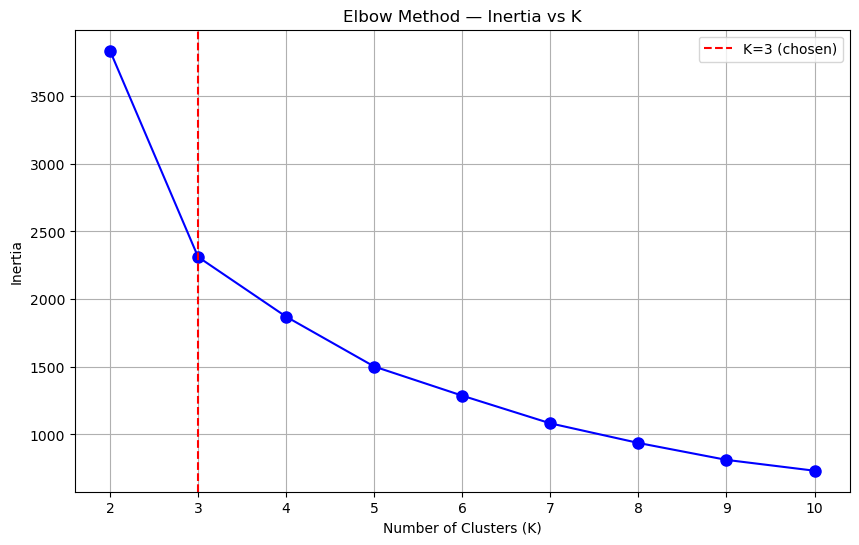

Inertia Score at K=3: 2311.9027


In [9]:
# Elbow plot (inertia)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bo-', markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='K=3 (chosen)')
plt.title('Elbow Method — Inertia vs K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)
plt.show()
print(f"Inertia Score at K=3: {inertia_values[1]:.4f}")

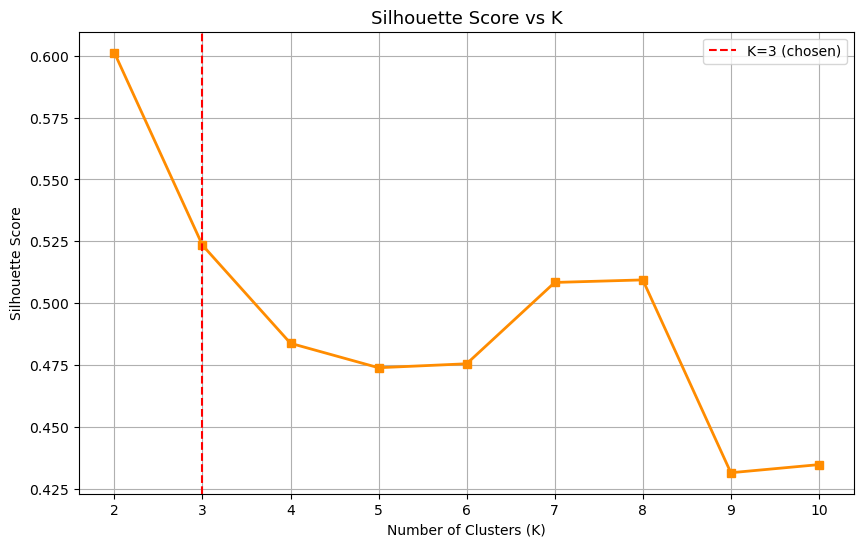

Silhouette Score at K=3: 0.5234


In [10]:
# Silhouette plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='s', color='darkorange', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', label='K=3 (chosen)')
plt.title('Silhouette Score vs K', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()
print(f"Silhouette Score at K=3: {scores[1]:.4f}")

In [11]:
# Fit final model (k=3)
optimal_k = 3

kmeans_pipeline = Pipeline([
    ('scaler', preprocessor),
    ('kmeans', KMeans(n_clusters=optimal_k, n_init=10, random_state=42))
])

df['KMeans_Cluster'] = kmeans_pipeline.fit_predict(df)

print("K-Means complete.")

K-Means complete.


In [12]:
import joblib
# Save the pipeline to a file
joblib.dump(kmeans_pipeline, 'kmeans_model.pkl')

print("Model exported successfully as 'kmeans_model.pkl'")

Model exported successfully as 'kmeans_model.pkl'


## PCA Analysis:

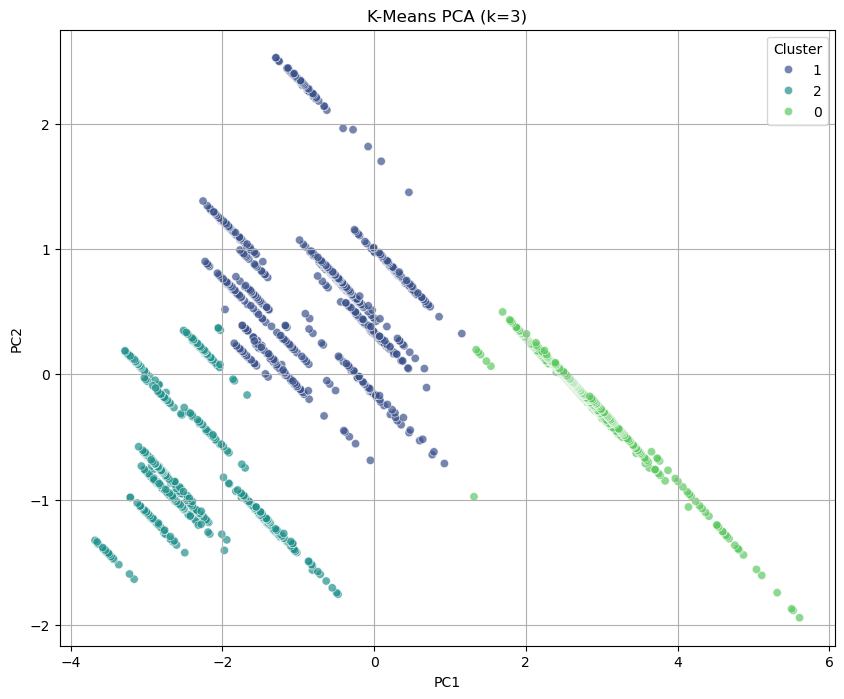

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['KMeans_Cluster'].astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.7)
plt.title(f'K-Means PCA (k={optimal_k})')
plt.grid(True)
plt.show()

## PCA Visualisation Analysis

The PCA (Principal Component Analysis) plot reduces the six features(Rent_Price, Land_Price, Population of County, Average_Value_County,
Net_Income, and Average_Value_Bedroom_Count) down to two principal components (PC1 and PC2) to allow visual inspection of the cluster structure.

**Key Observations:**

**Cluster Separation:**
The three clusters are modestly seperated across the PC1 axis, confirming that K-means has indentified genuine different groupings in the data. This is a strong indicator that the three-tier pricing structure (Budget, Standard, Luxury) is supported by the underlying data.

**PC1 as the Primary Driver:**
The clusters are spread primiarly along the horizontal axis (PC1), suggesting that PC1 captures the kost siginifcant variation between  property tiers, which is consistent with expectations. PC1 likely refelcts a mixture of high-value features such as Rent_Price, Land_Price and Net_Income, which are the strongest differentiators between Budget Standard and Luxury properties in the Irish market.


**Business Implication:**
The clear visual seperation between clusters, particulariuly between Budget(Cluster 2) and Luxury (Cluster 0), validates that the model can reliably distinguish betweeen the extremes of the pricing scale. For ourselves as a property development business, this illustrates that the K-means model provides a dependable  automated methods for classifying new developemnts into pricing tiers based on county level market indicators, to be used a tool alongside manual judgement from domain experts.


In [14]:
# Print cluster summary for insight
cluster_summary = df.groupby('KMeans_Cluster')[features].mean()
print(cluster_summary)
# Mapping clusters to tier names
cluster_to_tier = {
    0: 'Luxury',    
    1: 'Standard',
    2: 'Budget'     
}

df['Cluster_Label'] = df['KMeans_Cluster'].map(cluster_to_tier)

                 Rent_Price    Land_Price  Population of County  \
KMeans_Cluster                                                    
0               1844.728563  18392.776097          1.447028e+06   
1               1087.907497  17445.676985          2.656726e+05   
2                854.794280  10953.238004          1.399606e+05   

                Average_Value_County    Net_Income  \
KMeans_Cluster                                       
0                        1837.931970  70853.748865   
1                        1093.160445  59763.306864   
2                         855.925963  52975.679463   

                Average_Value_Bedroom_Count  
KMeans_Cluster                               
0                               1843.289818  
1                               1089.187457  
2                                854.794280  


## Cluster Centroid Analysis

The table below shows the mean feature values for each K-Means cluster,
which was used to determine the correct mapping of cluster numbers to
pricing tiers.

| Feature | Cluster 0 (Luxury) | Cluster 1 (Standard) | Cluster 2 (Budget) |
|---|---|---|---|
| Rent_Price (€) | 1,844.73 | 1,087.91 | 854.79 |
| Land_Price (€) | 18,392.78 | 17,445.67 | 10,953.24 |
| Population of County | 1,447,028 | 2,656,726 | 1,399,606 |
| Average_Value_County | 1,837.93 | 1,093.16 | 855.93 |
| Net_Income (€) | 70,053.75 | 59,763.31 | 52,975.68 |
| Average_Value_Bedroom_Count | 1,843.29 | 1,089.19 | 854.79 |

**Key Observations:**

**Cluster 0 : Luxury**
Cluster 0 has the highest values across all features, most notably a mean Rent_Price of €1,844 and an Average_Value_County of €1,837. The Net_Income of €70,053 reflects the wealthiest county demographics. This clearly corresponds to the luxury pricing tier, capturing high-value properties in premium Irish locations such as Dublin and its surrounding cimmuter counties.

**Cluster 1 : Standard**
Cluster 1 sits firmly in the middle across all features, with a
mean Rent_Price of €1,087 and Net_Income of €59,763. These values
are consistent with mid-range properties in moderately prosperous
Irish counties, confirming this cluster represents the Standard
pricing tier.

**Cluster 2 : Budget**
Cluster 2 has the lowest values across every feature, with a mean
Rent_Price of €854 and the lowest Land_Price of €10,953. The lower
Net_Income of €52,975 reflects counties with lower economic
activity and affordability levels, confirming this cluster
corresponds to the Budget pricing tier.

**Business Implication:**
The clear and consistent ordering of all six features across the
three clusters with no feature contradicting the tier hierarchy
validates that the cluster mapping is robust and not coincidental.
This confirms that the K-Means algorithm has identified genuine
economic stratification in the Irish property market, providing
a reliable and interpretable basis for automated pricing tier
assignment.

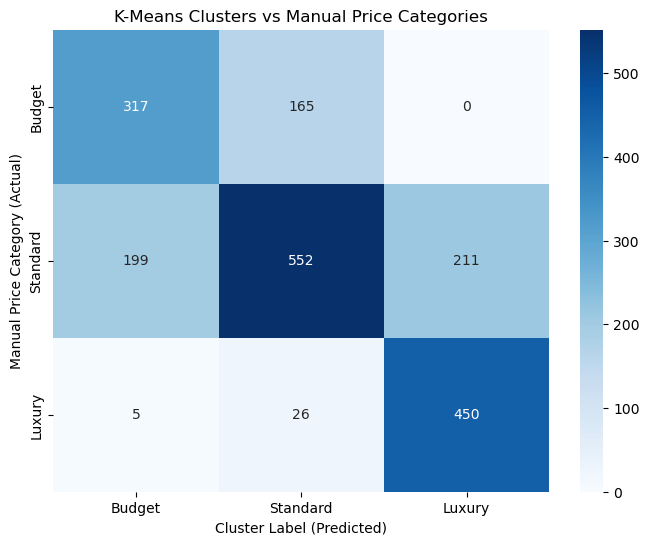

              precision    recall  f1-score   support

      Budget       0.61      0.66      0.63       482
    Standard       0.74      0.57      0.65       962
      Luxury       0.68      0.94      0.79       481

    accuracy                           0.69      1925
   macro avg       0.68      0.72      0.69      1925
weighted avg       0.69      0.69      0.68      1925



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Define consistent label order
labels = ['Budget', 'Standard', 'Luxury']

cm = confusion_matrix(df['Price_Category'], df['Cluster_Label'], labels=labels)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('K-Means Clusters vs Manual Price Categories')
plt.xlabel('Cluster Label (Predicted)')
plt.ylabel('Manual Price Category (Actual)')
plt.show()

# Text report
print(classification_report(df['Price_Category'], df['Cluster_Label'], labels=labels))

## Confusion Matrix Analysis

The model achieves an overall accuracy of 69%, which is a strong result for an unsupervised algorithm that was never shows the lables during training. This suggets the three-tier pricing structure (Budget, Standard, Luxury) reflects genuine, data-driven distinctions in the Irish proprty market.

Price Category Breakdown:

**Luxury**: performs the best with recall of 94%, meaning the model correctly indentifed 450 out of 481 Luxury properties. This makes intuitive sense as Luxury properties in high-value counties (ie Dublin) have very distinct Rent_Price, Land_price and Net_Income values that seperate them frok other tiers.

**Budget**: achieves 66% recall, identifyig 317 of 482 Budget proprties. The 165 misclassified as Standard likely represent properties in counties where budget tier rents overlap with standard tier pricing, which is a known characteristic of the Irish rentla markey especially outside major urban centres.

**Standard**: shows the weakest recall at 57%, correctly identifying 552 of 962 properties. This is something we expected to see as Standard is the middle tier and naturally shares feature overlap with both Budget and Luxury at its boundaries. 199 Standard properties were assigned to Budget and 211 to Luxury, reflecting the continuous nature of property pricing in practice.

**Business Implication:**

The strong performance on Luxury (F1: 0.79) and reasonable performance on Budget (F1: 0.63) is particularly valuable for a property developer. Correctly identifying premium developments avoids under-pricing, which directly protects revenue. The weaker Standard performance highlights that mid-range pricing decisions may benefit from additional features such as proximity to Eircode zones or local amenity data to sharpen tier boundaries in future iterations of the model.